### Citi Bike Prediction Project — Exploratory Data Analysis

The goal of this exploratory analysis is to better understand the temporal, spatial, and operational patterns in Citi Bike station activity, with a focus on identifying conditions that lead to low dock availability.

Specifically, this analysis aims to:
- Evaluate the distribution of the target variable (low dock availability)
- Identify temporal patterns (hour of day, day of week)
- Examine station-level behavior and geographic trends
- Assess feature relationships that may inform predictive modeling

These insights will guide feature engineering and model selection in subsequent steps.

#### Load libraries

In [1]:
# Core analysis libraries
import pandas as pd
import numpy as np
import datetime
import time

# File path locations
from pathlib import Path

# Load data pull libraries
import requests
import json

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot styling
sns.set()

# Show all columns
pd.set_option('display.max_columns', None)

#### File directories

In [2]:
# File paths
PROJECT_ROOT = Path.cwd().resolve().parent
CLEAN_DATA_DIR = PROJECT_ROOT / "data/clean_data"
RAW_DATA_DIR = PROJECT_ROOT / "data/raw_data"
MODELS_DIR = PROJECT_ROOT / "models"
SRC_DIR = PROJECT_ROOT / "src"
DEPLOYMENT_DIR = PROJECT_ROOT / "deployment"

#### Import and Inspect Data

In this section, I load the processed Citi Bike dataset and perform initial inspection to understand its structure, data types, and completeness.

Each row represents a snapshot of a station at a specific point in time, including station attributes, availability metrics, and engineered features used for modeling.

In [3]:
# Load data saved as a parquet file
data = pd.read_parquet(CLEAN_DATA_DIR / "01_citi_bike_prediction_preprocessing.parquet")

In [4]:
# Number of rows and columns
data.shape

(718733, 16)

In [5]:
# Show first five records of data
data.head(5)

,station_id,num_bikes_available,num_docks_available,snapshot_hr,snapshot_weekday,citi_bike_station_name,citi_bike_lat,citi_bike_lon,capacity,meters_to_nearest_mta_station,current_dock_pct,future_num_docks_available,future_snapshot_time,future_dock_pct,minutes_to_future,lda_30min
0,00284700-9d22-42ce-8485-113fed9879c1,10,8,4,6,28 Ave & 44 St,40.764089,-73.910651,19.0,893.80959,0.421053,6.0,2026-03-22 04:37:35,0.315789,30.0,0
1,00284700-9d22-42ce-8485-113fed9879c1,12,6,4,6,28 Ave & 44 St,40.764089,-73.910651,19.0,893.80959,0.315789,8.0,2026-03-22 05:07:35,0.421053,30.0,0
2,00284700-9d22-42ce-8485-113fed9879c1,10,8,5,6,28 Ave & 44 St,40.764089,-73.910651,19.0,893.80959,0.421053,8.0,2026-03-22 05:37:35,0.421053,30.0,0
3,00284700-9d22-42ce-8485-113fed9879c1,10,8,5,6,28 Ave & 44 St,40.764089,-73.910651,19.0,893.80959,0.421053,8.0,2026-03-22 06:07:35,0.421053,30.0,0
4,00284700-9d22-42ce-8485-113fed9879c1,10,8,6,6,28 Ave & 44 St,40.764089,-73.910651,19.0,893.80959,0.421053,8.0,2026-03-22 06:37:35,0.421053,30.0,0


In [6]:
# Data types along with count of missing
data_types_and_counts = pd.DataFrame()
data_types_and_counts["Data Type"] = data.dtypes
data_types_and_counts["Count of Nulls"] = data.isna().sum()
data_types_and_counts

,Data Type,Count of Nulls
station_id,object,0
num_bikes_available,int64,0
num_docks_available,int64,0
snapshot_hr,int32,0
snapshot_weekday,int32,0
citi_bike_station_name,object,0
citi_bike_lat,float64,0
citi_bike_lon,float64,0
capacity,float64,0
meters_to_nearest_mta_station,float64,0


#### Target variable breakdown

The target variable represents whether a station will experience low dock availability within the next 30 minutes.

The distribution shows a moderate class imbalance, with approximately 15% of observations labeled as high risk.

This reflects real-world system behavior, where most stations operate normally while a smaller subset experiences capacity issues.

In [7]:
data["lda_30min"].value_counts(normalize=True)

lda_30min
0    0.846733
1    0.153267
Name: proportion, dtype: float64

#### Highest average future availability

This section highlights stations with the highest average future dock availability.

These stations are consistently well-balanced, with sufficient dock capacity over time. They likely represent areas with lower demand pressure or effective redistribution.

In [8]:
data.groupby("citi_bike_station_name").agg({
    "future_dock_pct":"mean"
}).sort_values(by="future_dock_pct", ascending=False).head(10)

,future_dock_pct
citi_bike_station_name,
Broadway & W 36 St,1.000000
Steuben Ave & E 210 St,0.990517
E Gun Hill Rd & Tryon Ave,0.989071
Prospect Ave & Longwood Ave,0.982179
Aqueduct Ave & North St,0.979358
Benham St & Roosevelt Ave,0.973624
93 St & Roosevelt Ave,0.971075
Edgecombe Ave & W 150 St,0.966055
Grand Concourse & E 203 St,0.961186


#### Lowest average future availability

Here we examine stations with the lowest average future dock availability.

These stations are more prone to congestion and capacity constraints, making them strong candidates for predictive modeling and operational intervention.

In [9]:
data.groupby("citi_bike_station_name").agg({
    "future_dock_pct":"mean"
}).sort_values(by="future_dock_pct", ascending=False).tail(15)

,future_dock_pct
citi_bike_station_name,
Graham Ave & Withers St,0.022256
3 St & 3 Ave,0.020865
56 Ave & 92 St,0.018716
Market St & Henry St,0.018276
99 St & 50 Ave,0.017621
101 St & Fort Hamilton Pkwy,0.016565
Schenectady Ave & Maple St,0.015612
Winthrop St & Schenectady Ave,0.015145
Bailey Ave & W 193 St,0.013828


#### Target variable by weekday

We analyze how the probability of low dock availability varies across the week.

The results show increasing risk during the workweek, with peak levels toward the end of the week, followed by a decline on weekends.

This pattern suggests that commuting behavior plays a significant role in system imbalance.

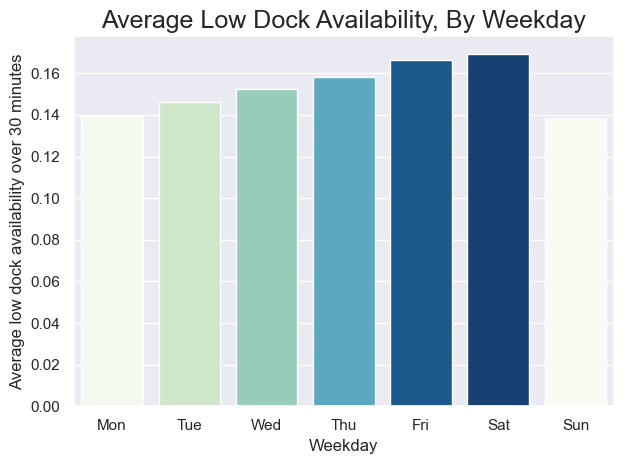

In [10]:
# Aggregate data
avg_lda_by_weekday = pd.DataFrame(data.groupby("snapshot_weekday")["lda_30min"].mean()).reset_index()

# Remap weekday numbers to names
weekday_map = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu",
    4: "Fri", 5: "Sat", 6: "Sun"
}

avg_lda_by_weekday["weekday_name"] = avg_lda_by_weekday["snapshot_weekday"].map(weekday_map)

# Plot data
sns.barplot(
    avg_lda_by_weekday, 
    x="weekday_name", 
    y="lda_30min",
    palette="GnBu",
    hue="lda_30min",
    legend=False
)

# Axes and title
plt.title("Average Low Dock Availability, By Weekday", fontsize=18)
plt.xlabel("Weekday")
plt.xticks(range(7))
plt.ylabel("Average low dock availability over 30 minutes")
plt.tight_layout()

plt.show()

#### Target by current dock percentage

We examine the relationship between current dock availability and future low dock risk.

As expected, stations with lower current dock percentages are more likely to experience low dock availability in the near future.

This indicates that current system state is a strong predictor of future conditions.

In [11]:
pd.DataFrame(data.groupby("citi_bike_station_name")["current_dock_pct"].mean().sort_values(ascending=False).head(10))

,current_dock_pct
citi_bike_station_name,
Broadway & W 36 St,1.000000
E Gun Hill Rd & Tryon Ave,0.988290
Steuben Ave & E 210 St,0.987931
Prospect Ave & Longwood Ave,0.982284
Aqueduct Ave & North St,0.979358
Benham St & Roosevelt Ave,0.973496
93 St & Roosevelt Ave,0.971203
Edgecombe Ave & W 150 St,0.966208
Grand Concourse & E 203 St,0.961186


#### Target variable percent by hour

We analyze how low dock availability varies by hour of the day.

Key observations:
- Higher risk during early morning hours, likely due to overnight imbalance
- Lower risk during midday as rider activity redistributes bikes
- Moderate increases during commuting periods

These findings highlight the importance of time-based features in modeling.

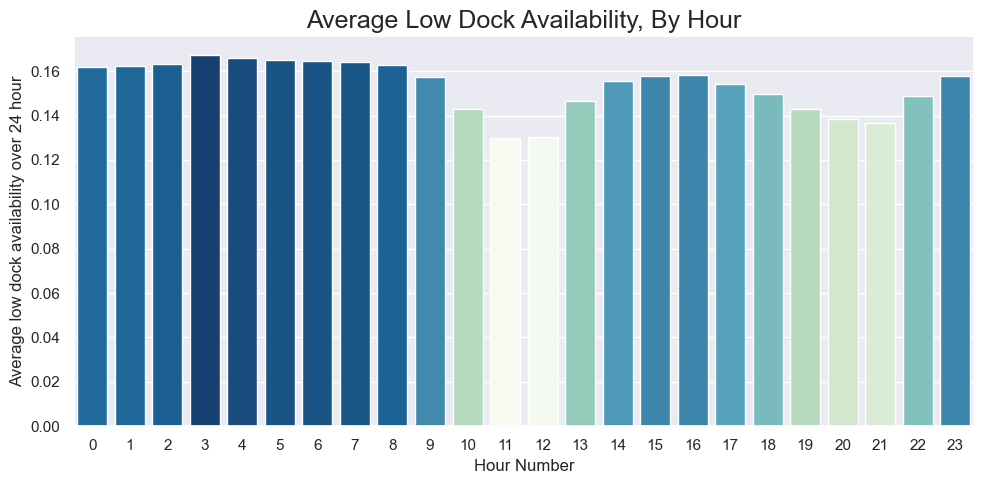

In [12]:
# Aggregate data
avg_lda_by_hr = pd.DataFrame(data.groupby("snapshot_hr")["lda_30min"].mean())

# Figure size
plt.figure(figsize=(10, 5))

# Plot data
sns.barplot(
    avg_lda_by_hr, 
    x="snapshot_hr", 
    y="lda_30min",
    palette="GnBu",
    hue="lda_30min",
    legend=False
)

# Axes and title
plt.title("Average Low Dock Availability, By Hour", fontsize=18)
plt.xlabel("Hour Number")
plt.xticks(range(24))
plt.ylabel("Average low dock availability over 24 hour")
plt.tight_layout()

plt.show()

#### Top 20 stations with highest available bikes

This section identifies stations with the highest number of available bikes.

These stations may serve as supply hubs within the network and provide insight into spatial imbalances in bike distribution.

In [13]:
# Plot
data.groupby("citi_bike_station_name")["lda_30min"].mean().sort_values(ascending=False).head(20)

citi_bike_station_name
E 116 St & 2 Ave                   1.000000
17 St & 5 Ave                      1.000000
E 51 St & 2 Ave                    1.000000
Mott St & Prince St                1.000000
Brooklyn Ave & Beverley Rd         1.000000
36 St & 3 Ave                      1.000000
Van Cleef St & 108 St              1.000000
111 St & 49 Ave                    1.000000
89 St & 3 Ave                      1.000000
Winthrop St & Schenectady Ave      1.000000
99 St & 50 Ave                     1.000000
3 St & 3 Ave                       1.000000
Bailey Ave & W 193 St              1.000000
Ave A & E 14 St                    1.000000
Naples Terrace & Godwin Terrace    0.996942
Martense Ave & 108 St              0.996942
56 Ave & 92 St                     0.993884
101 St & Fort Hamilton Pkwy        0.987768
60 Ave & Otis Ave                  0.987768
47 Ave & 104 St                    0.972477
Name: lda_30min, dtype: float64

#### Plot each station

Visualization of station locations across New York City using geographic coordinates.

Marker size represents average dock availability, while color reflects station capacity.

This visualization helps identify spatial clusters and geographic patterns in station utilization.

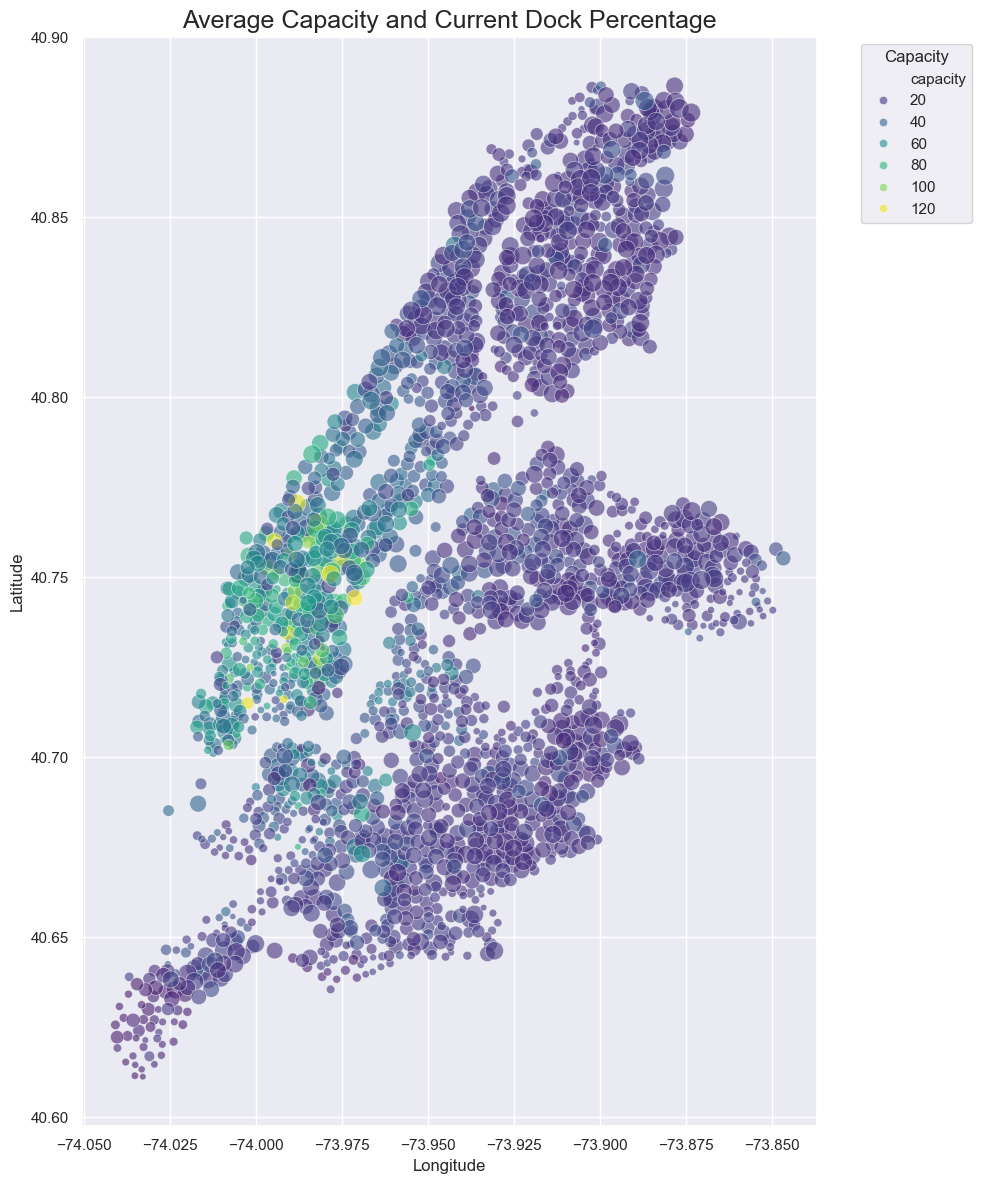

In [14]:
# Aggregate data
station_plot_data = pd.DataFrame(
    data.groupby(["station_id", "citi_bike_station_name", "citi_bike_lat", "citi_bike_lon", "capacity"], 
                 as_index=False).agg(avg_dock_pct=("current_dock_pct", "mean"))
)

plt.figure(figsize=(10,12))

# Plot data
scatter = sns.scatterplot(
    data=station_plot_data, 
    y="citi_bike_lat", 
    x="citi_bike_lon", 
    size="avg_dock_pct", 
    hue="capacity", 
    alpha=0.6,
    palette="viridis",
    sizes=(20, 200)
)

# Clean up legend
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles[:len(handles)//2], labels[:len(labels)//2], title="Capacity",
           bbox_to_anchor=(1.05, 1), loc="upper left")

# Axes and label names
plt.title("Average Capacity and Current Dock Percentage", fontsize=18)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

plt.show()

#### Top station risk

I calculated the average probability of low dock availability for each station and identify the highest-risk locations.

A small subset of stations consistently exhibits high risk, indicating persistent demand imbalance and making them critical targets for predictive modeling.

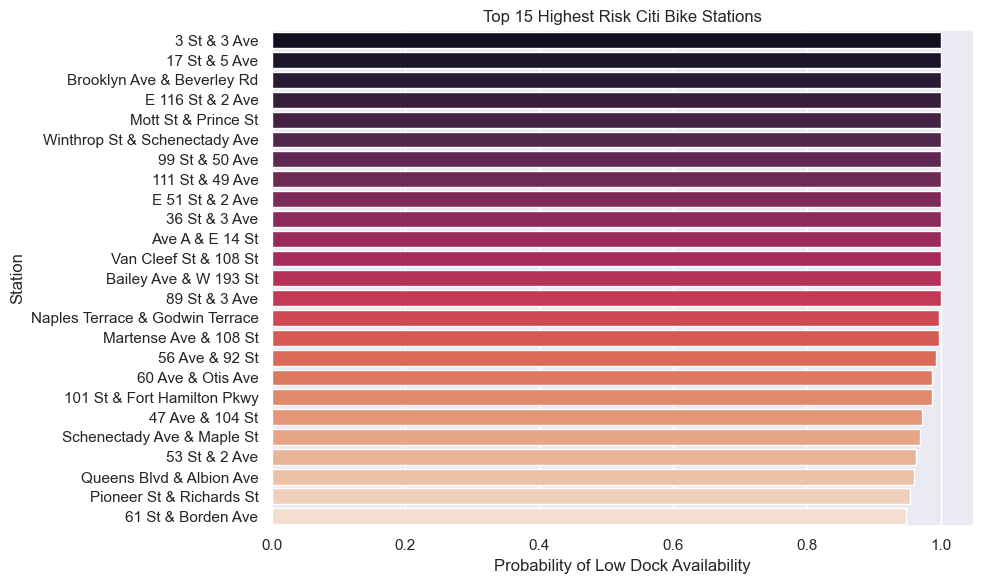

In [15]:
# Aggregate data
station_risk = (
    data
    .groupby(["station_id", "citi_bike_station_name"], as_index=False)
    .agg(low_dock_rate=("lda_30min", "mean"))
    .sort_values("low_dock_rate", ascending=False)
)

# Figure size
plt.figure(figsize=(10,6))

# Plot data
sns.barplot(
    data=station_risk.head(25),
    x="low_dock_rate",
    y="citi_bike_station_name", 
    hue="citi_bike_station_name",
    palette="rocket"
)

# Axes labels and title
plt.title("Top 15 Highest Risk Citi Bike Stations")
plt.xlabel("Probability of Low Dock Availability")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

#### Distribution of Station-Level Low Dock Risk

The distribution of station-level risk is highly right-skewed.

- Most stations rarely experience low dock availability
- A small number of stations account for a disproportionate share of risk

This highlights strong spatial heterogeneity and reinforces the importance of station-level features.

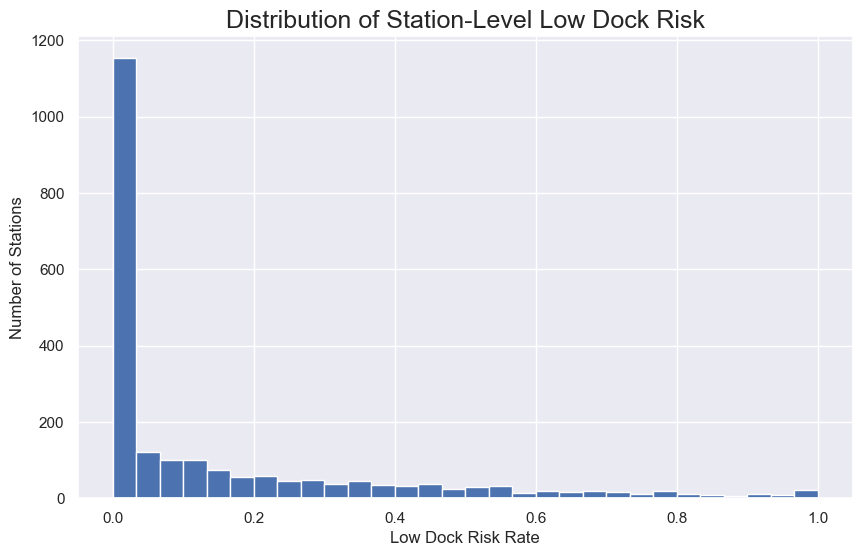

In [16]:
plt.figure(figsize=(10,6))
station_risk["low_dock_rate"].hist(bins=30)
plt.title("Distribution of Station-Level Low Dock Risk", fontsize=18)
plt.xlabel("Low Dock Risk Rate")
plt.ylabel("Number of Stations")
plt.show()